## Source Review

In [1]:
# import computation and analytical libraries

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import point

# import visualization libraries 
import folium as fl
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

## 1.) Colorado State Department of Local Affairs - special maps -> school district data (.shp).

In [9]:
# read co school district file

shpfile = '../data/co_school_districts_data/dlschool.shp'

gdf_dla = gpd.read_file(shpfile)

In [10]:
gdf_dla.head()

,source,lastupdate,LG_ID,NAME,LG_TYPE_ID,LG_STATUS_,ABBREV_NAM,MAIL_ADDRE,ALT_ADDRES,MAIL_CITY,MAIL_STATE,MAIL_ZIP,WEBSITE_UR,PREV_NAME,OBJECTID_1,geometry
0,Census TIGER SHP 2023,August 2024,36900,Trinidad 1 School District,99.0,1.0,Trinidad 1 School District,215 South Maple Street,NA,Trinidad,CO,81082,www.tsd1.org/,NA,1014,"POLYGON ((-104.82995 37.26398, -104.82348 37.2..."
1,Census TIGER SHP 2023,August 2024,64945,Wiley RE-13 JT School District,99.0,1.0,Wiley RE-13 JT School District,PO Box 247,NA,Wiley,CO,81092,www.wileyschool.org/,NA,2115,"POLYGON ((-102.83465 38.18648, -102.83457 38.2..."
2,Census TIGER SHP 2023,August 2024,64901,Brighton 27J School District,99.0,1.0,Brighton 27J School District,18551 East 160th Avenue,NA,Brighton,CO,80601,www.brightonps27j.k12.co.us,NA,2071,"MULTIPOLYGON (((-104.76267 39.80558, -104.7626..."
3,Census TIGER SHP 2023,August 2024,28900,Huerfano RE-1 School District,99.0,1.0,Huerfano RE-1 School District,611 West 7th Street,NA,Walsenburg,CO,81089,www.huerfano.k12.co.us/,NA,653,"POLYGON ((-105.50168 37.59814, -105.5013 37.59..."
4,Census TIGER SHP 2023,August 2024,56900,Silverton 1 School District,99.0,1.0,Silverton 1 School District,PO Box 128,NA,Silverton,CO,81433-0128,www.silvertonschool.org,NA,1503,"POLYGON ((-107.97507 37.68365, -107.97238 37.6..."


(array([ 29,  31,  34,  48, 159]),)

In [11]:
gdf_dla.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   source      178 non-null    object  
 1   lastupdate  178 non-null    object  
 2   LG_ID       178 non-null    object  
 3   NAME        178 non-null    object  
 4   LG_TYPE_ID  178 non-null    float64 
 5   LG_STATUS_  178 non-null    float64 
 6   ABBREV_NAM  178 non-null    object  
 7   MAIL_ADDRE  178 non-null    object  
 8   ALT_ADDRES  178 non-null    object  
 9   MAIL_CITY   178 non-null    object  
 10  MAIL_STATE  178 non-null    object  
 11  MAIL_ZIP    178 non-null    object  
 12  WEBSITE_UR  178 non-null    object  
 13  PREV_NAME   178 non-null    object  
 14  OBJECTID_1  178 non-null    int32   
 15  geometry    178 non-null    geometry
dtypes: float64(2), geometry(1), int32(1), object(12)
memory usage: 21.7+ KB


reviewing the dataset summary, we can also see that there isn't missingness in any of the fields.

In [12]:
gdf_dla.columns

Index(['source', 'lastupdate', 'LG_ID', 'NAME', 'LG_TYPE_ID', 'LG_STATUS_',
       'ABBREV_NAM', 'MAIL_ADDRE', 'ALT_ADDRES', 'MAIL_CITY', 'MAIL_STATE',
       'MAIL_ZIP', 'WEBSITE_UR', 'PREV_NAME', 'OBJECTID_1', 'geometry'],
      dtype='object')

In [16]:
gdf_dla.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

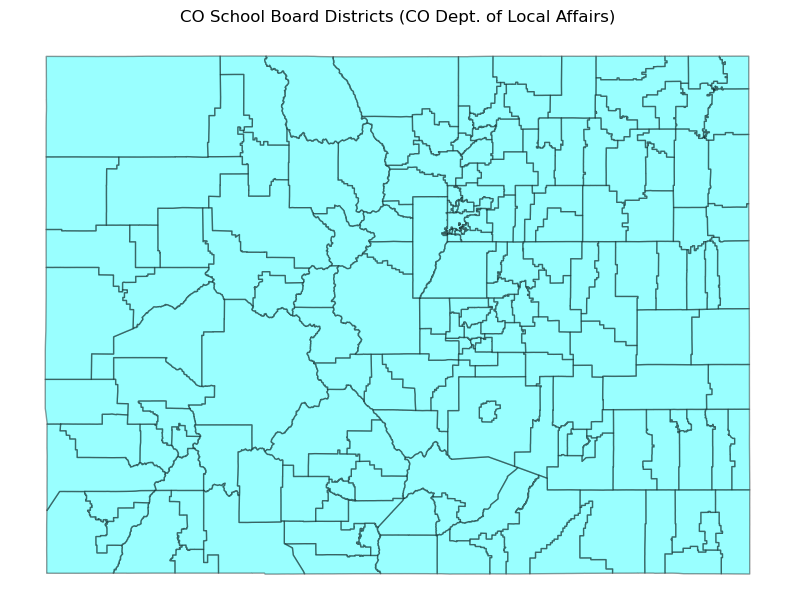

In [14]:
# plot schoolboard counties in CO via CO state department of Local Affairs
gdf_dla.plot(figsize=(10,10),color='cyan', edgecolor = "black", alpha=0.4)
plt.title("CO School Board Districts (CO Dept. of Local Affairs)")
plt.axis("off")
plt.show()

In [18]:
gdf_dla.NAME.nunique()

178

  
Colorado Department of State Affairs data on school districts is district-representation complete based on a google search of how many school board districts there are in the state.  

In [19]:
gdf_dla.lastupdate.value_counts()

lastupdate
August 2024    178
Name: count, dtype: int64

  
All records present in data set were last verified or updated in August 2024 as shown by the count of unique values for the `lastupdated` field.


In [20]:
gdf_dla.source.value_counts()

source
Census TIGER SHP 2023    178
Name: count, dtype: int64

In [21]:
gdf_dla.PREV_NAME.value_counts()

PREV_NAME
NA                                        173
Maher 50(J) School District                 1
Eagle County RE 50 School District          1
Northglenn-Thornton 12 School District      1
Pueblo City 60 School District              1
North Park R-1 School District              1
Name: count, dtype: int64

the unique values within the `PREV_NAME` field suggest that 5 out of the 178 school districts were once labeled under different names. This suggests perhaps districts might have had their boundaries withdrawn and names changed to reflect that alteration. To make sure i will look at the records that are not `NA` valued to inspect their new names. 

In [28]:
gdf_dla[gdf_dla.PREV_NAME != 'NA']

,source,lastupdate,LG_ID,NAME,LG_TYPE_ID,LG_STATUS_,ABBREV_NAM,MAIL_ADDRE,ALT_ADDRES,MAIL_CITY,MAIL_STATE,MAIL_ZIP,WEBSITE_UR,PREV_NAME,OBJECTID_1,geometry
29,Census TIGER SHP 2023,August 2024,64916,Delta County School District 50(J),99.0,1.0,Delta County School District 50(J),7655 2075 Road,NA,Delta,CO,81416,www.deltaschools.com,Maher 50(J) School District,2086,"POLYGON ((-108.60102 38.50074, -108.59748 38.6..."
31,Census TIGER SHP 2023,August 2024,64919,Eagle County School District RE50J,99.0,1.0,Eagle County School District RE50J,PO Box 740,NA,Eagle,CO,81631,www.eagleschools.net,Eagle County RE 50 School District,2089,"POLYGON ((-107.43178 39.83025, -107.43161 39.8..."
34,Census TIGER SHP 2023,August 2024,01901,Adams 12 Five Star Schools,99.0,1.0,Adams 12 Five Star Schools,1500 E 128th Avenue,NA,Thornton,CO,80241,www.adams12.org,Northglenn-Thornton 12 School District,5434,"POLYGON ((-105.05311 39.93029, -105.05292 39.9..."
48,Census TIGER SHP 2023,August 2024,51902,Pueblo City Schools,99.0,1.0,Pueblo City Schools,315 West 11th Street,NA,Pueblo,CO,81003,www.pueblocityschools.us/,Pueblo City 60 School District,1399,"POLYGON ((-104.73621 38.28533, -104.71764 38.2..."
159,Census TIGER SHP 2023,August 2024,29900,North Park School District R-1,99.0,1.0,North Park School District R-1,PO Box 798,NA,Waldon,CO,0480,sites.google.com/northpark.k12.co.us/home/our-...,North Park R-1 School District,661,"POLYGON ((-106.87323 40.97364, -106.87308 40.9..."


**AI USE:** I did a google search to understand the changes in the identifier adjustments and couldnt find definitions. I prompted an llm to give me potential reasons for the name changes of the type occuring in the above entries. It mentioned that its possible a naming convention just changed (e.g. a letter removed) and it reflects standardization or removal of outdated classification codes or state reporting updates. It also suggests the case of a district merger or consolidation where the new district keeps its name but the other district adopts the name of the other. This doesnt seem to be the case with most of these entries since most are only adding a identifier (letter or number) or removing it. In reference to the identifier additions (a 'J' in entry 29, for example) signifies that it has been classified as 'Joint' meaning that the district crosses general legal county lines. Also defines 'RE' as reorganized and 'R' as rural and that a district may add or remove these identifiers as said legal structures evolve. 

I verified the llm output by doing a review of its mentioned resources on District Identifiers (LEA ID, NCES ID, and State District codes). Then knowing the correct terms for the identifiers. I did a google search and found resources on the different classification IDs.

**design doc note** 

District identifier (LEA ID, NCES ID, state district code) — if the identifier remains the same, the district likely persisted through a simple rename.
Geographic boundaries — compare shapefiles across years.
Enrollment counts — large jumps may indicate mergers or boundary changes.
State education records from the Colorado Department of Education.

A useful rule of thumb is:

If only the name changed but the district ID remained constant, the change is usually administrative or cosmetic. If both the name and district ID changed, the change is more likely related to a merger, split, or reorganization affecting district boundaries.

# 2.)